# 04 · Leading indicators: does 311 activity come before crime?

The "broken windows" idea is that physical disorder (streetlights out, vacant buildings, dumping,
graffiti) precedes some kinds of crime. The project's 311 data makes that testable, area by area and
month by month. This notebook runs the method notebook `05_leading_indicators` runs nightly, using the
pandas reference in `src/leading_indicators.py`, and shows why each step is there.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent   # run from the repo root or tutorials/
sys.path[:0] = [str(ROOT), str(ROOT / "tutorials")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _data
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#898781"])})
pd.set_option("display.width", 160, "display.max_columns", 30)
print("data from:", _data.source())

from src import leading_indicators as li
from src.community_areas import AREA_NAMES

sr = _data.sr_monthly()
crime = _data.crime_monthly_by_category()
months = sorted(set(sr["period"]) & set(crime["period"]))[:-1]        # shared, complete months only
monthly = pd.concat([sr, crime], ignore_index=True)
monthly = monthly[monthly["period"].isin(months)]
print(f"{monthly['metric'].nunique()} metrics x 77 areas x {len(months)} months ({months[0]} to {months[-1]})")

data from: local exports


19 metrics x 77 areas x 90 months (2019-03-01 to 2026-08-01)


## The naive correlation is huge, and meaningless

Correlate streetlight-out complaints with property crime across every area-month:

raw correlation, log counts: r = 0.53


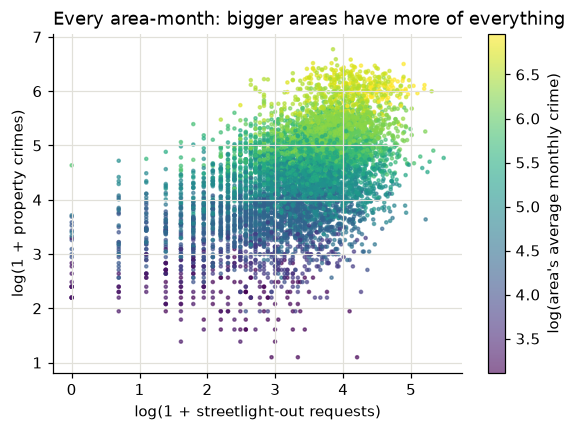

In [2]:
pair = monthly.pivot_table(index=["community_area", "period"], columns="metric", values="metric_count")
x, y = np.log1p(pair["311_streetlight_out"]), np.log1p(pair["crime_property"])
print(f"raw correlation, log counts: r = {x.corr(y):.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
size = pair.groupby(level=0)["crime_total"].transform("mean")
sc = ax.scatter(x, y, c=np.log(size), s=4, cmap="viridis", alpha=0.6)
ax.set_xlabel("log(1 + streetlight-out requests)"); ax.set_ylabel("log(1 + property crimes)")
ax.set_title("Every area-month: bigger areas have more of everything", loc="left")
plt.colorbar(sc, label="log(area's average monthly crime)"); plt.show()

That correlation mostly says **big, busy areas have more of everything**, and **summer lifts both**.
Neither is a leading signal. So, per metric, take out each area's own average and each month's citywide
average (two-way demeaning). What's left is "this area was unusually high or low this month, for itself
and for the season".

In [3]:
resid = li.residuals(monthly)
r = resid.pivot_table(index=["community_area", "period"], columns="metric", values="resid")
print(f"after demeaning, same month: r = {r['311_streetlight_out'].corr(r['crime_property']):.3f}")

after demeaning, same month: r = 0.005


## Does 311 lead?

Now the real question: does a 311 type running unusually high in month *t − k* go with a crime category
running unusually high in month *t*, for k = 1-3 months? And to rule out "both are just responding to the
same thing", the same correlation in the **reverse** direction (crime leading 311) must be weaker, as must
the same-month correlation. With 11 × 8 pairs × 4 lags × 2 directions, the significance bar is
Bonferroni-corrected across all of them.

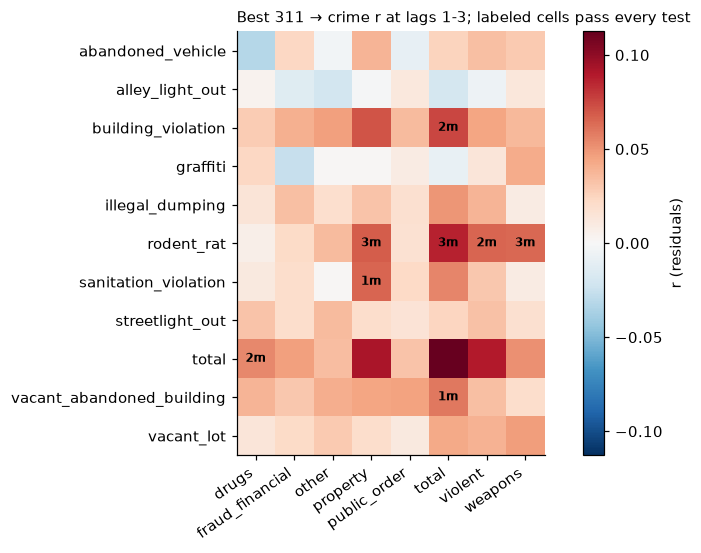

8 of 88 pairs flagged as leading


,sr_metric,crime_metric,lag_months,r,n,p_value,reverse_r,lag0_r,is_leading
309,311_rodent_rat,crime_total,3,0.087,6699,0.0,0.069,0.048,True
197,311_building_violation,crime_total,2,0.075,6776,0.0,0.071,0.071,True
307,311_rodent_rat,crime_property,3,0.068,6699,0.0,0.053,0.053,True
222,311_rodent_rat,crime_violent,2,0.065,6776,0.0,0.062,0.042,True
139,311_sanitation_violation,crime_property,1,0.065,6853,0.0,0.042,0.051,True
311,311_rodent_rat,crime_weapons,3,0.065,6699,0.0,0.044,0.056,True
165,311_vacant_abandoned_building,crime_total,1,0.059,6853,0.0,0.042,0.047,True
240,311_total,crime_drugs,2,0.054,6776,0.0,0.034,0.042,True


In [4]:
table = li.lead_lag(monthly)
best = (table[table["lag_months"] >= 1].sort_values("r", ascending=False)
        .groupby(["sr_metric", "crime_metric"]).head(1))
grid = best.pivot(index="sr_metric", columns="crime_metric", values="r")
flagged = best[best["is_leading"]]

fig, ax = plt.subplots(figsize=(9, 5))
lim = np.nanmax(np.abs(grid.values))
im = ax.imshow(grid.values, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.set_xticks(range(len(grid.columns)), [c.removeprefix("crime_") for c in grid.columns], rotation=35, ha="right")
ax.set_yticks(range(len(grid.index)), [s.removeprefix("311_") for s in grid.index])
for _, f in flagged.iterrows():
    i, j = list(grid.index).index(f["sr_metric"]), list(grid.columns).index(f["crime_metric"])
    ax.text(j, i, f"{f['lag_months']}m", ha="center", va="center", fontsize=8, fontweight="bold")
ax.grid(False)
ax.set_title("Best 311 → crime r at lags 1-3; labeled cells pass every test", loc="left", fontsize=10)
plt.colorbar(im, label="r (residuals)"); plt.show()
print(f"{len(flagged)} of {len(best)} pairs flagged as leading")
flagged.sort_values("r", ascending=False).round(3).head(10)

Some of the strongest cells aren't flagged. 311 volume overall tracks crime overall, but just as strongly
the other way round or in the same month, so it isn't *leading* anything. The flagged ones survive every
test, rodent complaints and building violations most of all.

For one pair, compare every lag in both directions. A "leading" pair shows the forward correlation
(311 first) peaking at a lag of a month or more, above the same-month and the reverse correlation:

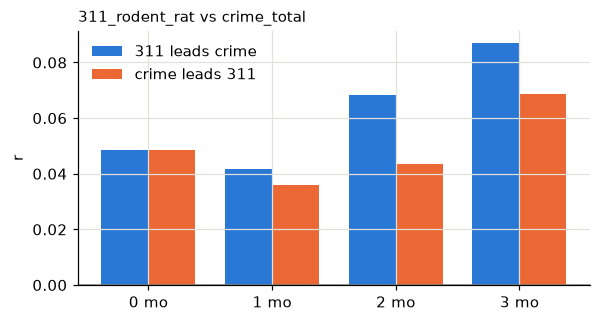

In [5]:
top = flagged.sort_values("r", ascending=False).iloc[0] if len(flagged) else best.iloc[0]
rows = table[(table["sr_metric"] == top["sr_metric"]) & (table["crime_metric"] == top["crime_metric"])]
fig, ax = plt.subplots(figsize=(6, 3))
w = 0.38
ax.bar(rows["lag_months"] - w / 2, rows["r"], w, label="311 leads crime")
ax.bar(rows["lag_months"] + w / 2, rows["reverse_r"], w, label="crime leads 311")
ax.axhline(0, color="#898781", lw=1)
ax.set_xticks(rows["lag_months"], [f"{k} mo" for k in rows["lag_months"]])
ax.set_title(f"{top['sr_metric']} vs {top['crime_metric']}", loc="left", fontsize=10)
ax.set_ylabel("r"); ax.legend(frameon=False); plt.show()

## The placebo

If the demeaning works, pairing each area's 311 history with a *different, random* area's crime should
find nothing: any correlation that survives the shuffle is a shared citywide signal leaking through, not
a local relationship.

In [6]:
placebo = li.placebo(monthly)
print(f"placebo (lag 1, shuffled areas): max |r| = {placebo['r'].abs().max():.3f}, median |r| = {placebo['r'].abs().median():.3f}")
print(f"real flagged pairs: r from {flagged['r'].min():.3f} to {flagged['r'].max():.3f}" if len(flagged) else "no flagged pairs")

placebo (lag 1, shuffled areas): max |r| = 0.045, median |r| = 0.013
real flagged pairs: r from 0.054 to 0.087


## How to read it, and how the app uses it

The correlations are small. That's expected: month-to-month swings in one area are mostly noise. And the
honest caveats travel with the result everywhere it appears in the app:
- **correlation, not causation**: a flagged pair means "historically, when this 311 type rose unusually in
  an area, this crime category tended to rise there k months later", nothing more;
- **a citywide pattern**, pooled across all 77 areas, not a claim about any one of them;
- **optimistic p-values**, because months within an area aren't independent. Bonferroni, the minimum
  effect size and the reverse test are there to keep that from flagging noise.

In the app, the flagged 311 types that are rising in an area right now become **signals to watch**, each
with a one-click alert on the 311 type itself (the early signal, not the crime it tends to precede).

A related negative result, from `offline_ml/`: adding 311 features to a crime *forecast* didn't help at
all. Recent crime already carries whatever 311 knows about next month, so 311's role in this project is
this descriptive signal, not a model input.

Next: [05 · Next-week outlook](05_next_week_outlook.ipynb), the forecasting model.